# Fine-tuning LoRA — Modèle médical expérimental (TechCorp)

A exécuter sur **Google Colab** (runtime GPU : `Runtime > Change runtime type > GPU`, T4 suffit).

- Base : `microsoft/Phi-3.5-mini-instruct`
- Dataset : `datasets/cleaned/medical_dataset_sample.json` (5000 dialogues patient/médecin nettoyés, voir `datasets/MEDICAL_DATA_QUALITY_REPORT.md`)
- Objectif : POC expérimental — **pas un déploiement production** (voir `medical_project/Readme.md`).

A la fin du notebook : l'adaptateur LoRA entraîné + les métriques (loss/epochs) sont sauvegardés. Pensez à partager le **lien Colab** et les métriques avec le reste de l'équipe.

In [1]:
!pip install -q transformers>=4.45.0 peft>=0.12.0 accelerate>=0.34.0 bitsandbytes>=0.43.0 datasets>=2.20.0

## 1. Récupérer le dataset

Deux options : cloner le repo (nécessite `git-lfs`), ou uploader `medical_dataset_sample.json` directement via le panneau Fichiers de Colab.

In [8]:
# Option A : clone du repo (remplacez l'URL par celle de votre remote)
!apt-get -qq install git-lfs
!git lfs install
!git clone https://github.com/BertaudNathan/hackathon_ynov_2026_grp_5.git repo
!cd repo && git lfs pull
DATASET_PATH = "repo/datasets/cleaned/medical_dataset_sample.json"

Git LFS initialized.
fatal: destination path 'repo' already exists and is not an empty directory.


In [3]:
# Option B (si l'option A échoue) : uploader medical_dataset_sample.json manuellement puis décommenter
from google.colab import files
uploaded = files.upload()
DATASET_PATH = "medical_dataset_sample.json"

In [10]:
import json

with open(DATASET_PATH, encoding="utf-8") as f:
    raw_data = json.load(f)

print(f"{len(raw_data)} exemples charg\u00e9s")
print(raw_data[0])

5000 exemples chargés
{'instruction': 'How to treat buttock pain in a 4 years old child?\nhello my daughter is nearly 4 years old and recently keeps complaining of pain in her bum during the day and at nite and theres no sign of redness or anything wrong, looks normal but its drivin me mad now not knowing wat 2 do with her only been putting on sudocrem, wat do u think it mite b? or is there anything else i cud do 2 help her with the discomfort.', 'output': "Hi...by what you say, I feel that this could be a worm infestation. This is even more possible as you say that the local examination is normal.You can use Albendazole at the appropriate dose. This is a prescription drug and you will require a doctor's prescription for this.Regards - Dr. Sumanth"}


## 2. Chargement du modèle de base (4-bit) + configuration LoRA

In [11]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training

BASE_MODEL = "microsoft/Phi-3.5-mini-instruct"

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
)

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=quantization_config,
    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.float16,
)
model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["qkv_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


trainable params: 15,204,352 || all params: 3,836,283,904 || trainable%: 0.3963


## 3. Préparation du dataset (format chat Phi-3)

In [12]:
from datasets import Dataset

def to_text(example):
    text = f"<|user|>\n{example['instruction']}<|end|>\n<|assistant|>\n{example['output']}<|end|>"
    return {"text": text}

texts = [to_text(x) for x in raw_data]
hf_dataset = Dataset.from_list(texts)

def tokenize_function(examples):
    tokenized = tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=512,
    )
    tokenized["labels"] = tokenized["input_ids"].copy()
    return tokenized

tokenized_dataset = hf_dataset.map(tokenize_function, batched=True, remove_columns=["text"])
tokenized_dataset

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 5000
})

## 4. Entraînement

In [14]:
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling

training_args = TrainingArguments(
    output_dir="./phi35_medical_lora_checkpoints",
    num_train_epochs=3,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    warmup_steps=50,
    logging_steps=25,
    save_steps=500,
    save_total_limit=2,
    remove_unused_columns=False,
    fp16=True,
    report_to="none",
    max_steps=150,
)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
)

train_result = trainer.train()

/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

Step,Training Loss
25,9.146797
50,8.504531
75,8.211683
100,8.073728
125,8.015566
150,7.965471


## 5. Sauvegarde du modèle + métriques (loss / epochs)

A partager avec l'équipe : le fichier `training_metrics.json`, le graphe de loss, et le lien de ce notebook Colab.

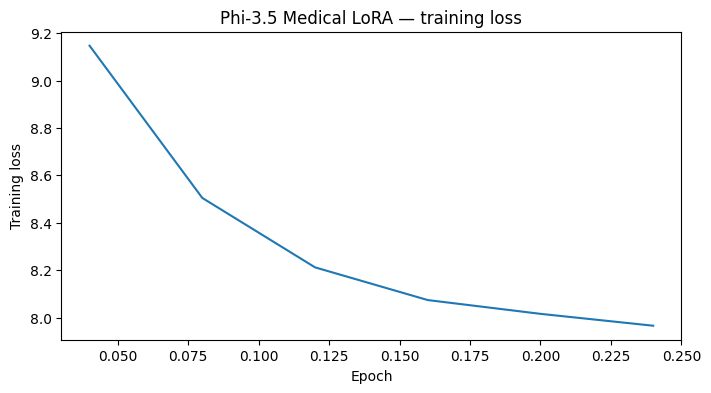

Loss initiale: 9.1468 -> Loss finale: 7.9655
Nombre d'epochs: 0.24


In [15]:
import json
import matplotlib.pyplot as plt

trainer.save_model("./phi35_medical_lora")
tokenizer.save_pretrained("./phi35_medical_lora")

log_history = trainer.state.log_history
with open("training_metrics.json", "w") as f:
    json.dump(log_history, f, indent=2)

losses = [(e["epoch"], e["loss"]) for e in log_history if "loss" in e]
if losses:
    epochs, loss_values = zip(*losses)
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, loss_values)
    plt.xlabel("Epoch")
    plt.ylabel("Training loss")
    plt.title("Phi-3.5 Medical LoRA — training loss")
    plt.savefig("training_loss.png")
    plt.show()
    print(f"Loss initiale: {loss_values[0]:.4f} -> Loss finale: {loss_values[-1]:.4f}")
    print(f"Nombre d'epochs: {epochs[-1]:.2f}")

## 6. Test rapide (validation conversationnelle)

⚠️ Modèle expérimental — les réponses ne constituent pas un avis médical (voir `medical_project/Readme.md`).

In [17]:
test_questions = [
    "I have had a headache and mild fever for two days, what could it be?",
    "What are common side effects of ibuprofen?",
    "How much water should I drink daily?",
]

model.eval()
for q in test_questions:
    formatted = f"<|user|>\n{q}<|end|>\n<|assistant|>\n"
    inputs = tokenizer(formatted, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=150,
            temperature=0.7,
            do_sample=True,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id,
            use_cache=False,
        )
    response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    print(f"Q: {q}\nR: {response}\n{'-'*60}")

/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

Q: I have had a headache and mild fever for two days, what could it be?
R: I and  my my had of is ? I. have i, I my I the the. a?, pain? and on, and I. and  a my,  I my in I my to. the to or...,. I,.. to,. be my a to the my and is is the the of in for 1 to
------------------------------------------------------------
Q: What are common side effects of ibuprofen?
R:  my ?
? a a. the a  the in a the? and  the I I,  my I a my my the. the the ,  I of   it the to and I  a of. I and is I have for and be. and a i the. I the is is I   of in a. it the... I I
------------------------------------------------------------
Q: How much water should I drink daily?
R: a
 in

 my a on,. a of, a I of to,
 pain,, and a for is and. and had a a, my a I  to I a. and. the.., I, my have. a the of. I I. and my and have pain and to a I a is.,,, with of a a. the,, to I, I.., the is.
------------------------------------------------------------


## 7. Récupération des livrables

Téléchargez `./phi35_medical_lora/` (adaptateur), `training_metrics.json` et `training_loss.png`, puis :
- placez l'adaptateur dans `medical_project/phi35_medical_lora/` du repo
- partagez le lien de ce notebook Colab + les métriques (loss, epochs) avec l'équipe pour le livrable final

In [18]:
!zip -r phi35_medical_lora.zip phi35_medical_lora training_metrics.json training_loss.png
from google.colab import files
files.download("phi35_medical_lora.zip")

  adding: phi35_medical_lora/ (stored 0%)
  adding: phi35_medical_lora/tokenizer_config.json (deflated 48%)
  adding: phi35_medical_lora/tokenizer.json (deflated 85%)
  adding: phi35_medical_lora/chat_template.jinja (deflated 61%)
  adding: phi35_medical_lora/README.md (deflated 65%)
  adding: phi35_medical_lora/training_args.bin (deflated 54%)
  adding: phi35_medical_lora/adapter_config.json (deflated 59%)
  adding: phi35_medical_lora/adapter_model.safetensors (deflated 7%)
  adding: training_metrics.json (deflated 66%)
  adding: training_loss.png (deflated 10%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>